# Geometric Probability Distribution

## 1. Definition

## 2. Intuition

<span style="color:red;">**How many trials are needed until the first success occurs?** </span>

Geometric = waiting time until the first Bernoulli success


## 3. Parameter

The Geometric distribution is parametrized by a single value, $\theta$, the probability that the Bernoulli trial is successful.

## 4. Support

The Geometric distribution, as defined here, has support on the nonnegative integers.

## 5. Probability Mass Function

$$P(X=n;\theta) = (1 - \theta)^{n-1}\theta$$

## 6. Cumulative Distribution Function

$$F(n;\theta) = 1-(1-\theta)^{n}$$


## 7. Moments

Mean: $\frac{1-\theta}{\theta}$

Variance: $\frac{1-\theta}{\theta^2}$

## 8. NumPy Implementation

In [1]:
import numpy as np
import matplotlib as plt

In [30]:
class Geometric:
    """
    Geometric distribution representing the number of trials
    required to obtain the first success.

    Support:
        {1, 2, 3, ...}
    """

    def __init__(self, theta: float):
        if not 0 < theta <= 1:
            raise ValueError("theta must be greater than 0 and at most 1.")

        self.theta = float(theta)

    def pmf(self, n):
        n = np.asarray(n)

        P = np.zeros_like(n, dtype=float)

        valid = (
            (n >= 1)
            & (n == np.floor(n))
        )

        n_valid = n[valid]

        P[valid] = (
            (1 - self.theta) ** (n_valid - 1)
            * self.theta
        )

        return P

    def cdf(self, n):
        n = np.asarray(n)

        F = np.zeros_like(n, dtype=float)

        valid = n >= 1

        F[valid] = (
            1
            - (1 - self.theta) ** np.floor(n[valid])
        )

        return F

    def mean(self):
        return 1 / self.theta

    def variance(self):
        return (1 - self.theta) / self.theta**2

    def sample(self, size=1, random_state=None):
        if not isinstance(size, (int, np.integer)):
            raise TypeError("size must be an integer.")

        if size < 1:
            raise ValueError("size must be at least 1.")

        rng = np.random.default_rng(random_state)

        uniform_samples = rng.random(size)

        samples = np.ceil(
            np.log1p(-uniform_samples)
            / np.log1p(-self.theta)
        )

        return samples.astype(int)

    def plot(self, max_n=15, figsize=(10, 4)):
        """
        Plot the PMF and CDF of the Geometric distribution.
    
        Parameters
        ----------
        max_n : int
            Maximum trial number to display.
        """
    
        import matplotlib.pyplot as plt
    
        support = np.arange(1, max_n + 1)
    
        pmf_values = self.pmf(support)
        cdf_values = self.cdf(support)
    
        fig, ax = plt.subplots(1, 2, figsize=figsize)
    
        # ---------------- PMF ----------------
        ax[0].bar(support, pmf_values)
    
        ax[0].set_title("Geometric PMF")
        ax[0].set_xlabel("Trial Number")
        ax[0].set_ylabel("Probability")
        ax[0].set_xticks(support)
        ax[0].grid(True, axis="y")
    
        # ---------------- CDF ----------------
        ax[1].step(support, cdf_values, where="post")
        ax[1].scatter(support, cdf_values)
    
        ax[1].set_title("Geometric CDF")
        ax[1].set_xlabel("Trial Number")
        ax[1].set_ylabel("Cumulative Probability")
        ax[1].set_xticks(support)
        ax[1].set_ylim(0, 1.05)
        ax[1].grid(True)
    
        plt.tight_layout()
        plt.show()

[0.         0.25       0.1875     0.140625   0.10546875]
[0.         0.25       0.4375     0.578125   0.68359375]
Mean: 4.0
Variance: 12.0
Samples: [ 6  3  7  5  1 13  5  6  1  3]


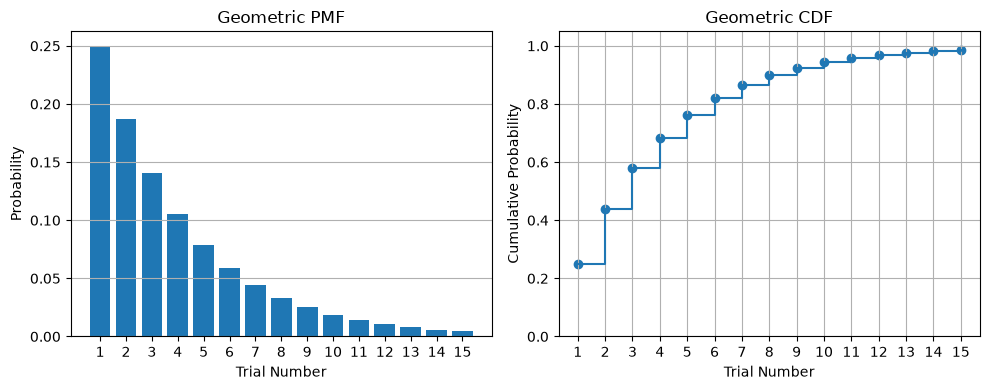

In [31]:
distribution = Geometric(theta=0.25)

print(distribution.pmf([0, 1, 2, 3, 4]))
print(distribution.cdf([0, 1, 2, 3, 4]))
print("Mean:", distribution.mean())
print("Variance:", distribution.variance())
print("Samples:", distribution.sample(size=10, random_state=42))

distribution.plot(max_n=15)